# Autograd - Build
This is the build section of the project, where new functions, classes, etc are created and tested. Finished peices are moved into main where they are then called and used by build.

More recently, this section is used to train models.

## Setup

In [20]:
import numpy as np
import main
from typing import Union, List
from matplotlib import pyplot as plt
import matplotlib_inline
import pandas as pd
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


In [21]:
# Organising the data

data = pd.read_csv(r"C:\Users\acart\OneDrive\Desktop\CodingProjects\mnist\mnist_train.csv")

data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

data_dev = data[0:10000]
Y_dev = data_dev[:, 0]
X_dev = data_dev[:, 1:] / 255.0

data_train = data[10000:m]
Y_train = data_train[:, 0]
X_train = data_train[:, 1:] / 255.0

print(X_train.shape)
print(Y_train.shape)
_, m_train = X_train.shape

(49999, 784)
(49999,)


In [22]:
# one hot gives: (num_samples, 10)
def one_hot(Y):
    Y = np.asarray(Y, dtype=int)
    one_hot_Y = np.zeros((Y.size, Y.max() + 1), dtype=np.float32)
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y

Y_train = one_hot(Y_train)
Y_dev = one_hot(Y_dev)

In [23]:
print(X_train.shape)   # should be (num_samples, 784)
print(Y_train.shape)   # should be (num_samples, 10)

(49999, 784)
(49999, 10)


## Creating a Model

In [24]:
model = main.Model(input_size=784, output_size=10, hidden_size=128,
              number_of_layers=4, activation_function=main.ReLU, normalisation_function=main.Softmax,
              random_seed=0, initialisation_function="He")


## Training a model

In [ ]:
# **Hyperparamaters **
num_epochs = 25
batch_size = 64
learning_rate = 0.05

custom_lr_schedular = [[1, 0.05], [2, 0.01], [20, 0.005]]

In [39]:
# Lists for data ploting
training_loss_over_time = []
validation_loss_over_time = []
validation_accuracy_over_time = []
epoch = 0

In [ ]:
# Deffining training using graident decent over a batched dataset

def train_model(model, X_train, Y_train, learning_rate, custom_lr_schedular=None, num_epochs=10, batch_size=64):
    epoch = 0
    while epoch < num_epochs:
        epoch += 1

        # Updating lr when a scheduled change is reached.
        if custom_lr_schedular is not None and custom_lr_schedular:
            while custom_lr_schedular and epoch >= custom_lr_schedular[0][0]:
                learning_rate = custom_lr_schedular[0][1]
                custom_lr_schedular.pop(0)

        # Shuffling the training data
        # np.random.permuation returns a list of random int between 0 and m_train. 
        # This is passed into numpy indexing to create a list from X_train in the specified order.
        permutation = np.random.permutation(len(X_train))
        X_train_shuffled = X_train[permutation]
        Y_train_shuffled = Y_train[permutation]

        epoch_loss = 0.0
        num_batches = int(np.ceil(m_train / batch_size))

        # Iterate over batches
        for b in range(num_batches):
            start_idx = b * batch_size
            end_idx = min(start_idx + batch_size, m_train)

            X_batch = X_train_shuffled[start_idx:end_idx]
            Y_batch = Y_train_shuffled[start_idx:end_idx]

            # Passing the batch through the model, running a backwards pass and updating paramaters
            batch_output = model.forward(X_batch)
            batch_loss = main.CrossEntropyLoss(batch_output, Y_batch)
            epoch_loss += batch_loss * (end_idx - start_idx)

            model.backwards(batch_output, Y_batch, main.CrossEntropyLoss)
            model.update_parameters(learning_rate)

        # Average training loss across all samples in the epoch
        average_training_loss = epoch_loss / m_train
        training_loss_over_time.append(average_training_loss)

        # Calculate actual model accuracy by comparing each prediction to the label, rather than aproximation using exp.
        train_predictions = np.argmax(model.forward(X_train), axis=1)
        train_targets = np.argmax(Y_train, axis=1)
        train_accuracy = np.mean(train_predictions == train_targets) * 100

        # The same as above for the validation set
        val_output = model.forward(X_dev)
        val_loss = main.CrossEntropyLoss(val_output, Y_dev)
        validation_loss_over_time.append(val_loss)

        val_predictions = np.argmax(val_output, axis=1)
        val_targets = np.argmax(Y_dev, axis=1)
        val_accuracy = np.mean(val_predictions == val_targets) * 100
        validation_accuracy_over_time.append(val_accuracy)

        # Printing the results of the current epoch
        print(
            f"Epoch: {epoch} | Train Loss: {round(average_training_loss, 2)} | Train Acc: {round(train_accuracy, 3)}% | "
            f"Val Loss: {round(val_loss, 3)} | Val Acc: {round(val_accuracy, 3)}% | Lr: {learning_rate}"
        )   

In [41]:
# Running the training loop
train_model(model, X_train, Y_train, learning_rate, custom_lr_schedular, num_epochs, batch_size)

Epoch: 1 | Train Loss: 0.26 | Train Acc: 92.154% | Val Loss: 0.29 | Val Acc: 91.45% | Lr: 0.05
Epoch: 2 | Train Loss: 0.34 | Train Acc: 92.224% | Val Loss: 0.288 | Val Acc: 91.39% | Lr: 0.01
Epoch: 3 | Train Loss: 0.2 | Train Acc: 92.21% | Val Loss: 0.288 | Val Acc: 91.58% | Lr: 0.01
Epoch: 4 | Train Loss: 0.27 | Train Acc: 92.332% | Val Loss: 0.282 | Val Acc: 91.62% | Lr: 0.01
Epoch: 5 | Train Loss: 0.24 | Train Acc: 92.44% | Val Loss: 0.285 | Val Acc: 91.64% | Lr: 0.01
Epoch: 6 | Train Loss: 0.27 | Train Acc: 92.498% | Val Loss: 0.278 | Val Acc: 91.94% | Lr: 0.01
Epoch: 7 | Train Loss: 0.24 | Train Acc: 92.444% | Val Loss: 0.28 | Val Acc: 91.64% | Lr: 0.01
Epoch: 8 | Train Loss: 0.24 | Train Acc: 92.434% | Val Loss: 0.281 | Val Acc: 91.65% | Lr: 0.01
Epoch: 9 | Train Loss: 0.26 | Train Acc: 92.368% | Val Loss: 0.284 | Val Acc: 91.53% | Lr: 0.01
Epoch: 10 | Train Loss: 0.26 | Train Acc: 92.558% | Val Loss: 0.277 | Val Acc: 91.84% | Lr: 0.01
Epoch: 11 | Train Loss: 0.28 | Train Acc: 92

KeyboardInterrupt: 

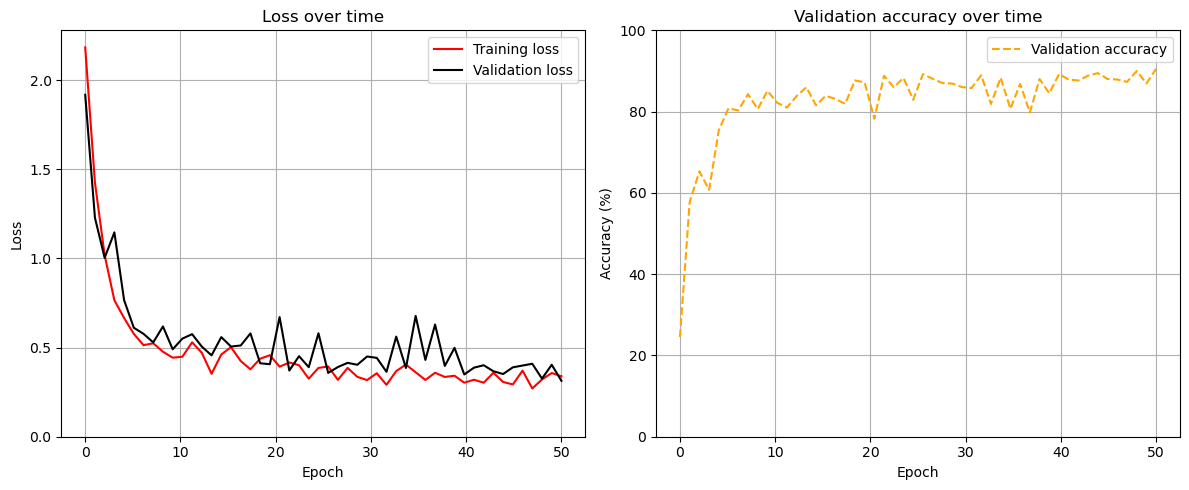

In [ ]:
# Plotting the loss and accuracy over time
x = np.linspace(0, len(training_loss_over_time), len(training_loss_over_time))
y1 = training_loss_over_time
y2 = validation_loss_over_time
y3 = validation_accuracy_over_time

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("Loss over time")
axes[0].plot(x, y1, label="Training loss", linestyle="-", color="red")
axes[0].plot(x, y2, label="Validation loss", linestyle="-", color="black")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_ylim(bottom=0)
axes[0].grid(True)
axes[0].legend()

axes[1].set_title("Validation accuracy over time")
axes[1].plot(x, y3, label="Validation accuracy", linestyle="--", color="orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 100)
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()